In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "student_id": range(1, n+1),
    "gender": np.random.choice(["M", "F"], n),
    "math_score": np.random.randint(40, 100, n),
    "reading_score": np.random.randint(45, 100, n),
    "writing_score": np.random.randint(42, 100, n),
    "attendance": np.random.randint(60, 100, n),
    "study_hours": np.random.randint(1, 7, n)
}

df = pd.DataFrame(data)

# Create final grade based on weighted logic
df["final_grade"] = (
    0.3 * df["math_score"] +
    0.3 * df["reading_score"] +
    0.3 * df["writing_score"] +
    0.1 * df["attendance"]
).round()

df.to_csv("student_data.csv", index=False)

print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   student_id gender  math_score  reading_score  writing_score  attendance  \
0           1      M          71             90             78          64   
1           2      F          78             62             63          88   
2           3      M          88             46             98          96   
3           4      M          91             98             70          97   
4           5      M          71             79             55          78   

   study_hours  final_grade  
0            2         78.0  
1            5         70.0  
2            2         79.0  
3            3         87.0  
4            3         69.0  


In [2]:
#Exploratory Data Analysis (EDA)

import pandas as pd

df = pd.read_csv("student_data.csv")

print(df.head())
print(df.info())

   student_id gender  math_score  reading_score  writing_score  attendance  \
0           1      M          71             90             78          64   
1           2      F          78             62             63          88   
2           3      M          88             46             98          96   
3           4      M          91             98             70          97   
4           5      M          71             79             55          78   

   study_hours  final_grade  
0            2         78.0  
1            5         70.0  
2            2         79.0  
3            3         87.0  
4            3         69.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   student_id     200 non-null    int64  
 1   gender         200 non-null    object 
 2   math_score     200 non-null    int64  
 3   reading_score  200 non

In [3]:
print(df.isnull().sum())

student_id       0
gender           0
math_score       0
reading_score    0
writing_score    0
attendance       0
study_hours      0
final_grade      0
dtype: int64


In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [5]:
print(df.describe())

       student_id  math_score  reading_score  writing_score  attendance  \
count  200.000000  200.000000     200.000000     200.000000  200.000000   
mean   100.500000   70.765000      74.385000      71.500000   79.200000   
std     57.879185   17.714366      15.863322      16.350126   11.760593   
min      1.000000   40.000000      45.000000      42.000000   60.000000   
25%     50.750000   57.000000      62.750000      57.000000   69.000000   
50%    100.500000   71.000000      75.500000      72.000000   79.000000   
75%    150.250000   87.000000      89.000000      86.000000   89.250000   
max    200.000000   99.000000      99.000000      99.000000   99.000000   

       study_hours  final_grade  
count   200.000000   200.000000  
mean      3.555000    72.905000  
std       1.775595     8.795041  
min       1.000000    46.000000  
25%       2.000000    68.000000  
50%       4.000000    72.000000  
75%       5.000000    79.000000  
max       6.000000    92.000000  


In [6]:
df["average_score"] = (
    df["math_score"] +
    df["reading_score"] +
    df["writing_score"]
) / 3

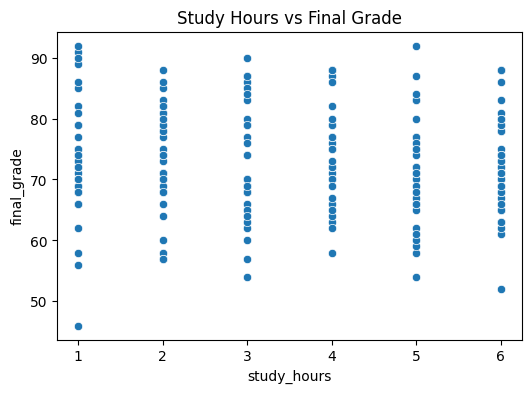

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(x="study_hours", y="final_grade", data=df)
plt.title("Study Hours vs Final Grade")
plt.show()

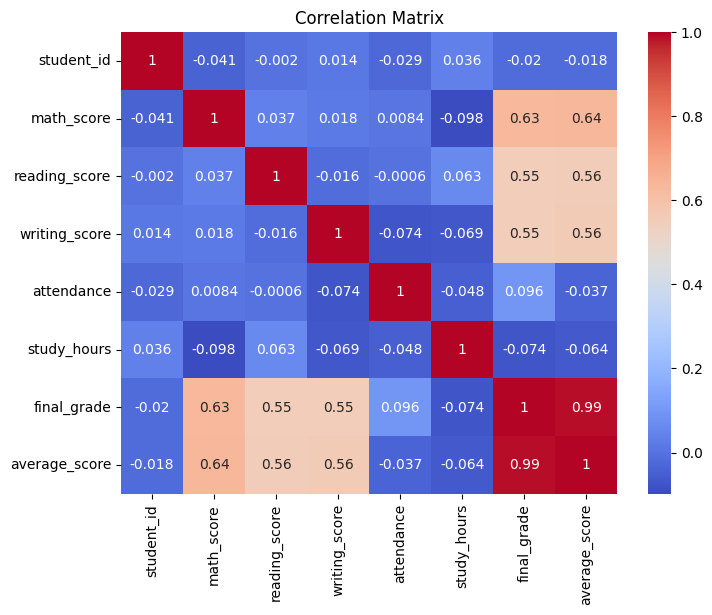

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [9]:
#Building a Predictive model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# selecyion of Features & Target

X = df[['study_hours', 'attendance', 'math_score', 'reading_score', 'writing_score']]
y = df['final_grade']

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
#Make Predictions
y_pred = model.predict(X_test)

In [14]:
# evaluate mosel

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.09019606221025253
R2 Score: 0.9991066988162475


In [15]:
#new student performance
new_student = [[4, 90, 85, 88, 87]]  
prediction = model.predict(new_student)

print("Predicted Final Grade:", prediction[0])

Predicted Final Grade: 86.9814543810469


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


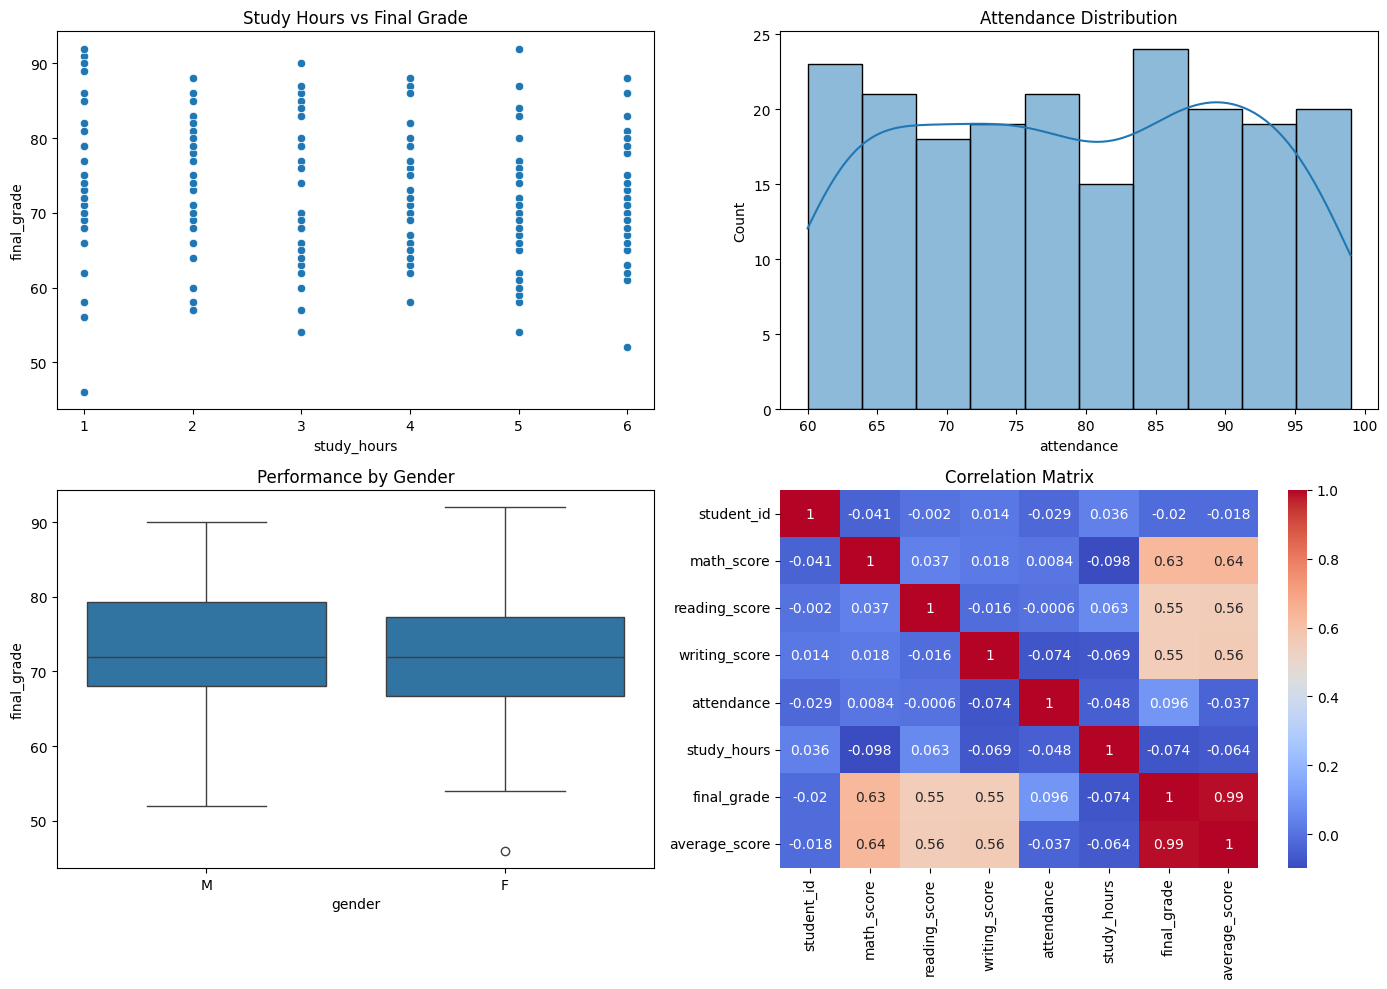

In [ ]:
# creating Dashboard

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

# 1️⃣ Study Hours vs Grade
plt.subplot(2,2,1)
sns.scatterplot(x="study_hours", y="final_grade", data=df)
plt.title("Study Hours vs Final Grade")

# 2️⃣ Attendance Distribution
plt.subplot(2,2,2)
sns.histplot(df["attendance"], bins=10, kde=True)
plt.title("Attendance Distribution")

# 3️⃣ Gender Performance
plt.subplot(2,2,3)
sns.boxplot(x="gender", y="final_grade", data=df)
plt.title("Performance by Gender")

# 4️⃣ Correlation Heatmap
plt.subplot(2,2,4)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()